<a href="https://colab.research.google.com/github/algaalex/Gaussian-Processes-GANs-GNNs/blob/main/01_part1_2d_gans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1 — Building and Understanding GANs from Scratch

This notebook completes the three assessed tasks:
1. reproduce a noisy sine-wave GAN;
2. model a new 2D mixture-of-Gaussians distribution;
3. compare a baseline and a modified architecture.





In [ ]:
import copy
import json
import math
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from scipy.spatial.distance import cdist
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import trange



In [ ]:
# ----------------------------- Configuration -----------------------------
QUICK_RUN = False
SEED = 42
LATENT_DIM = 16
BATCH_SIZE = 256
TRAINING_STEPS = 600 if QUICK_RUN else 5_000
LEARNING_RATE = 2e-4
OUTPUT_DIR = Path("outputs/part1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


def set_seed(seed: int = SEED) -> None:
    """Make repeated runs as reproducible as the selected backend permits."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()



Using device: cuda


## 1. Synthetic data generators

Both functions return tensors with shape `(number_of_samples, 2)`. The first
distribution is a noisy sine wave. The second contains eight Gaussian modes,
making it possible to see whether the GAN misses clusters (mode collapse).



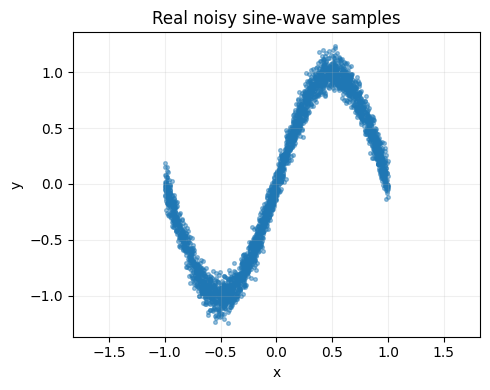

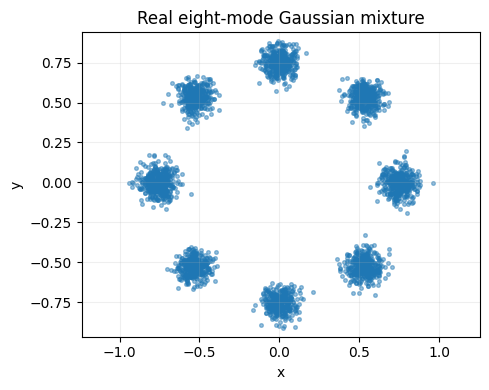

In [ ]:
def sample_sine(n: int, noise_std: float = 0.08, device=DEVICE) -> torch.Tensor:
    x = torch.empty(n, 1, device=device).uniform_(-math.pi, math.pi)
    y = torch.sin(x) + noise_std * torch.randn_like(x)
    # Scale x to approximately the same range as y for easier GAN optimisation.
    return torch.cat((x / math.pi, y), dim=1)


def sample_gaussian_mixture(
    n: int,
    radius: float = 0.75,
    cluster_std: float = 0.055,
    n_modes: int = 8,
    device=DEVICE,
) -> torch.Tensor:
    angles = torch.arange(n_modes, device=device) * (2 * math.pi / n_modes)
    centres = torch.stack((radius * torch.cos(angles), radius * torch.sin(angles)), dim=1)
    mode_ids = torch.randint(0, n_modes, (n,), device=device)
    return centres[mode_ids] + cluster_std * torch.randn(n, 2, device=device)


def plot_distribution(samples: torch.Tensor, title: str, path: Path | None = None) -> None:
    values = samples.detach().cpu().numpy()
    plt.figure(figsize=(5, 4))
    plt.scatter(values[:, 0], values[:, 1], s=7, alpha=0.45)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()


plot_distribution(sample_sine(3_000), "Real noisy sine-wave samples")
plot_distribution(sample_gaussian_mixture(3_000), "Real eight-mode Gaussian mixture")



## 2. Reusable GAN models

`BCEWithLogitsLoss` is used, so the discriminator returns a raw logit rather
than applying a sigmoid itself. This is numerically more stable.



In [ ]:
def activation_layer(name: str) -> nn.Module:
    if name.lower() == "relu":
        return nn.ReLU(inplace=True)
    if name.lower() == "leakyrelu":
        return nn.LeakyReLU(0.2, inplace=True)
    if name.lower() == "elu":
        return nn.ELU(inplace=True)
    raise ValueError(f"Unknown activation: {name}")


class MLPGenerator(nn.Module):
    def __init__(
        self,
        latent_dim: int = LATENT_DIM,
        hidden_dims: tuple[int, ...] = (64, 64),
        activation: str = "relu",
        batch_norm: bool = False,
    ):
        super().__init__()
        layers: list[nn.Module] = []
        input_dim = latent_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            if batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(activation_layer(activation))
            input_dim = hidden_dim
        # Tanh matches real samples that are scaled approximately to [-1, 1].
        layers.extend((nn.Linear(input_dim, 2), nn.Tanh()))
        self.network = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.network(z)


class MLPDiscriminator(nn.Module):
    def __init__(
        self,
        hidden_dims: tuple[int, ...] = (64, 64),
        activation: str = "leakyrelu",
    ):
        super().__init__()
        layers: list[nn.Module] = []
        input_dim = 2
        for hidden_dim in hidden_dims:
            layers.extend((nn.Linear(input_dim, hidden_dim), activation_layer(activation)))
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, points: torch.Tensor) -> torch.Tensor:
        return self.network(points).view(-1)


@dataclass
class GANResult:
    generator: nn.Module
    discriminator: nn.Module
    generator_losses: list[float]
    discriminator_losses: list[float]


def train_2d_gan(
    real_sampler,
    generator: nn.Module,
    discriminator: nn.Module,
    steps: int = TRAINING_STEPS,
    batch_size: int = BATCH_SIZE,
    latent_dim: int = LATENT_DIM,
    learning_rate: float = LEARNING_RATE,
) -> GANResult:
    """Train a vanilla GAN against a callable that samples fresh real points."""
    generator = generator.to(DEVICE)
    discriminator = discriminator.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimiser_g = torch.optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
    optimiser_d = torch.optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))

    g_losses: list[float] = []
    d_losses: list[float] = []
    progress = trange(steps, desc="Training GAN")

    for step in progress:
        # ------------------------ Train discriminator ------------------------
        real = real_sampler(batch_size)
        z = torch.randn(batch_size, latent_dim, device=DEVICE)
        fake = generator(z).detach()

        optimiser_d.zero_grad(set_to_none=True)
        real_logits = discriminator(real)
        fake_logits = discriminator(fake)
        d_loss_real = criterion(real_logits, torch.ones_like(real_logits))
        d_loss_fake = criterion(fake_logits, torch.zeros_like(fake_logits))
        d_loss = 0.5 * (d_loss_real + d_loss_fake)
        d_loss.backward()
        optimiser_d.step()

        # -------------------------- Train generator --------------------------
        optimiser_g.zero_grad(set_to_none=True)
        z = torch.randn(batch_size, latent_dim, device=DEVICE)
        generated = generator(z)
        generated_logits = discriminator(generated)
        g_loss = criterion(generated_logits, torch.ones_like(generated_logits))
        g_loss.backward()
        optimiser_g.step()

        g_losses.append(float(g_loss.item()))
        d_losses.append(float(d_loss.item()))
        if step % 250 == 0 or step == steps - 1:
            progress.set_postfix(g=f"{g_loss.item():.3f}", d=f"{d_loss.item():.3f}")

    return GANResult(generator, discriminator, g_losses, d_losses)


@torch.no_grad()
def generate_points(generator: nn.Module, n: int = 5_000) -> torch.Tensor:
    generator.eval()
    z = torch.randn(n, LATENT_DIM, device=DEVICE)
    return generator(z).cpu()


def plot_losses(result: GANResult, title: str, path: Path) -> None:
    plt.figure(figsize=(7, 4))
    plt.plot(result.generator_losses, label="Generator", alpha=0.85)
    plt.plot(result.discriminator_losses, label="Discriminator", alpha=0.85)
    plt.xlabel("Training step")
    plt.ylabel("Binary cross-entropy loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()



## 3. Task 1 — Sine-wave GAN



Training GAN:   0%|          | 0/5000 [00:00<?, ?it/s]

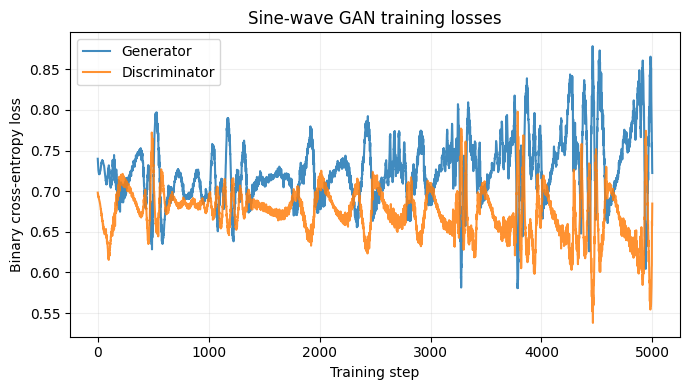

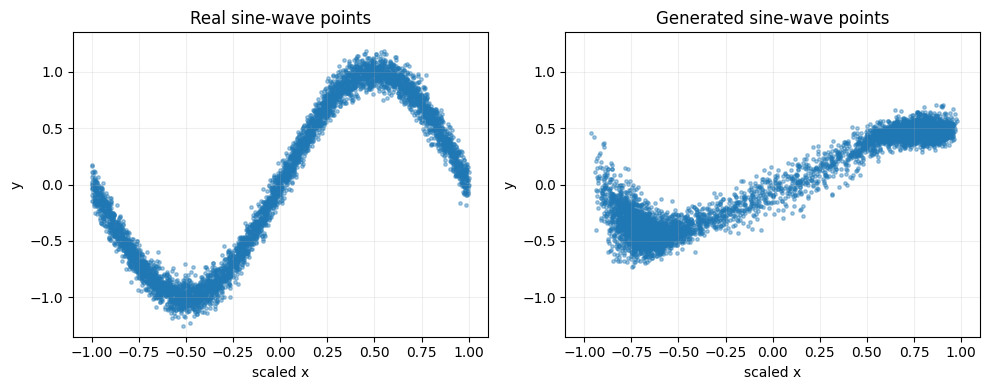

In [ ]:
set_seed(SEED)
sine_result = train_2d_gan(
    sample_sine,
    MLPGenerator(hidden_dims=(64, 64), activation="relu"),
    MLPDiscriminator(hidden_dims=(64, 64), activation="leakyrelu"),
)

real_sine = sample_sine(5_000, device="cpu")
fake_sine = generate_points(sine_result.generator)
plot_losses(sine_result, "Sine-wave GAN training losses", OUTPUT_DIR / "sine_losses.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, data, title in zip(
    axes,
    (real_sine, fake_sine),
    ("Real sine-wave points", "Generated sine-wave points"),
):
    values = data.numpy()
    axis.scatter(values[:, 0], values[:, 1], s=6, alpha=0.4)
    axis.set_title(title)
    axis.set_xlabel("scaled x")
    axis.set_ylabel("y")
    axis.set_xlim(-1.1, 1.1)
    axis.set_ylim(-1.35, 1.35)
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sine_real_vs_generated.png", dpi=220, bbox_inches="tight")
plt.show()



## 4. Tasks 2 and 3 — New distribution and architecture comparison

The baseline has two 64-unit layers and ReLU activations. The modified
generator is deeper and wider, uses LeakyReLU and batch normalisation. Other
training settings remain fixed to make the comparison fair.



Training GAN:   0%|          | 0/5000 [00:00<?, ?it/s]

Training GAN:   0%|          | 0/5000 [00:00<?, ?it/s]

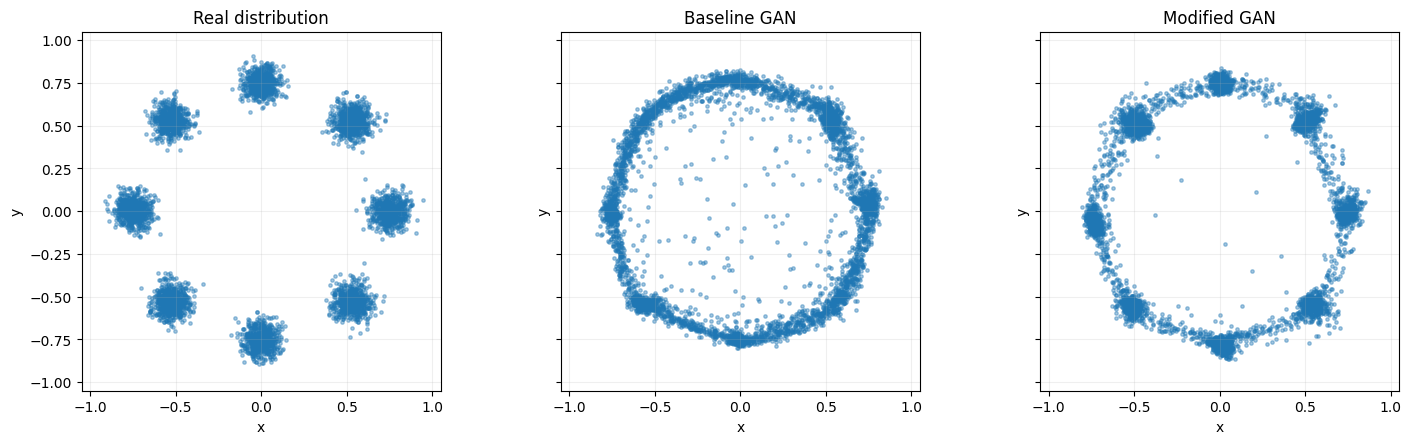

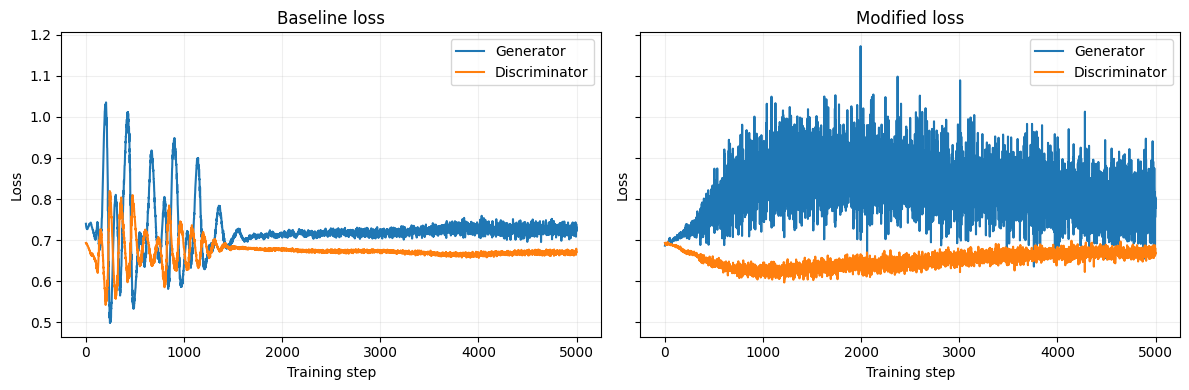

In [ ]:
set_seed(SEED)
mixture_baseline = train_2d_gan(
    sample_gaussian_mixture,
    MLPGenerator(hidden_dims=(64, 64), activation="relu", batch_norm=False),
    MLPDiscriminator(hidden_dims=(64, 64), activation="leakyrelu"),
)

set_seed(SEED)
mixture_modified = train_2d_gan(
    sample_gaussian_mixture,
    MLPGenerator(
        hidden_dims=(128, 128, 64),
        activation="leakyrelu",
        batch_norm=True,
    ),
    MLPDiscriminator(hidden_dims=(128, 128, 64), activation="leakyrelu"),
)

real_mixture = sample_gaussian_mixture(5_000, device="cpu")
fake_baseline = generate_points(mixture_baseline.generator)
fake_modified = generate_points(mixture_modified.generator)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
datasets = (real_mixture, fake_baseline, fake_modified)
titles = ("Real distribution", "Baseline GAN", "Modified GAN")
for axis, data, title in zip(axes, datasets, titles):
    values = data.numpy()
    axis.scatter(values[:, 0], values[:, 1], s=6, alpha=0.4)
    axis.set_title(title)
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    axis.set_xlim(-1.05, 1.05)
    axis.set_ylim(-1.05, 1.05)
    axis.set_aspect("equal")
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mixture_architecture_comparison.png", dpi=220, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, result, title in zip(
    axes,
    (mixture_baseline, mixture_modified),
    ("Baseline loss", "Modified loss"),
):
    axis.plot(result.generator_losses, label="Generator")
    axis.plot(result.discriminator_losses, label="Discriminator")
    axis.set_title(title)
    axis.set_xlabel("Training step")
    axis.set_ylabel("Loss")
    axis.grid(alpha=0.2)
    axis.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mixture_loss_comparison.png", dpi=220, bbox_inches="tight")
plt.show()



## 5. Quantitative comparison with maximum mean discrepancy (MMD)





In [ ]:
def rbf_mmd(x: np.ndarray, y: np.ndarray, max_samples: int = 2_000) -> float:
    """Biased RBF-kernel MMD with a median-distance bandwidth heuristic."""
    rng = np.random.default_rng(SEED)
    x = x[rng.choice(len(x), size=min(max_samples, len(x)), replace=False)]
    y = y[rng.choice(len(y), size=min(max_samples, len(y)), replace=False)]
    combined = np.vstack((x, y))
    bandwidth_sample = combined[
        rng.choice(len(combined), size=min(800, len(combined)), replace=False)
    ]
    distances = cdist(bandwidth_sample, bandwidth_sample, metric="sqeuclidean")
    positive = distances[distances > 0]
    sigma_squared = float(np.median(positive)) if len(positive) else 1.0

    def kernel(a: np.ndarray, b: np.ndarray) -> np.ndarray:
        return np.exp(-cdist(a, b, metric="sqeuclidean") / (2 * sigma_squared + 1e-12))

    return float(kernel(x, x).mean() + kernel(y, y).mean() - 2 * kernel(x, y).mean())


summary = pd.DataFrame(
    [
        {
            "experiment": "sine_baseline",
            "mmd": rbf_mmd(real_sine.numpy(), fake_sine.numpy()),
            "final_generator_loss": np.mean(sine_result.generator_losses[-100:]),
            "final_discriminator_loss": np.mean(sine_result.discriminator_losses[-100:]),
        },
        {
            "experiment": "mixture_baseline",
            "mmd": rbf_mmd(real_mixture.numpy(), fake_baseline.numpy()),
            "final_generator_loss": np.mean(mixture_baseline.generator_losses[-100:]),
            "final_discriminator_loss": np.mean(mixture_baseline.discriminator_losses[-100:]),
        },
        {
            "experiment": "mixture_modified",
            "mmd": rbf_mmd(real_mixture.numpy(), fake_modified.numpy()),
            "final_generator_loss": np.mean(mixture_modified.generator_losses[-100:]),
            "final_discriminator_loss": np.mean(mixture_modified.discriminator_losses[-100:]),
        },
    ]
)
summary.to_csv(OUTPUT_DIR / "part1_metrics.csv", index=False)
display(summary.round(4))



,experiment,mmd,final_generator_loss,final_discriminator_loss
0,sine_baseline,0.0409,0.7586,0.6432
1,mixture_baseline,0.0003,0.7240,0.6698
2,mixture_modified,0.0003,0.7890,0.6718


In [ ]:
# Save model weights and configuration so the results can be reproduced.
torch.save(sine_result.generator.state_dict(), OUTPUT_DIR / "sine_generator.pt")
torch.save(mixture_baseline.generator.state_dict(), OUTPUT_DIR / "mixture_baseline_generator.pt")
torch.save(mixture_modified.generator.state_dict(), OUTPUT_DIR / "mixture_modified_generator.pt")

configuration = {
    "quick_run": QUICK_RUN,
    "seed": SEED,
    "latent_dim": LATENT_DIM,
    "batch_size": BATCH_SIZE,
    "training_steps": TRAINING_STEPS,
    "learning_rate": LEARNING_RATE,
    "device": str(DEVICE),
}
(OUTPUT_DIR / "configuration.json").write_text(json.dumps(configuration, indent=2))
print(f"Part 1 complete. Outputs saved to {OUTPUT_DIR.resolve()}")


Part 1 complete. Outputs saved to /content/outputs/part1
